# The Deep Learning Tensor Engine (NumPy)

**Scenario:**
In Machine Learning, we rarely work with just a single image or a single number. Instead, we work with complex structures like batches of images (3D Arrays) and performance logs (Structured Arrays). More importantly, deep learning requires heavy matrix multiplications, shape transformations, and lightning-fast execution. 

**Your Mission:**
In the following cells, you will build an AI data pipeline step-by-step. Fill in the blanks (`___`) and run each cell to see the results immediately!

#### Step 1: Imports & 3D Slicing
Import the NumPy library. Then, from the 3D `image_batch`, select the **second image** (index 1) and crop it to extract ONLY its **last two columns** (index 1 to end).

In [2]:
import numpy as np

image_batch = np.array([
    [[1, 2, 3], [4, 5, 6], [7, 8, 9]],          # Image 1 (Index 0)
    [[10, 20, 30], [40, 50, 60], [70, 80, 90]]  # Image 2 (Index 1)
])

sub_region = image_batch[1, :, 1:]

print("Cropped Region:\n", sub_region)

Cropped Region:
 [[20 30]
 [50 60]
 [80 90]]


#### Step 2: Sequences, Math & Smart Filtering
1. Create a sequence of numbers from `0` to `10` (exclusive) with a step of `2`.
2. Apply the exponential math function (`exp`).
3. Filter the original sequence to keep only numbers strictly greater than `3`.

In [3]:
range_arr = np.arange(0, 10, 2)
exp_arr = np.exp(range_arr)

cond = range_arr > 3
filtered_vals = range_arr[cond]

print("Sequence:", range_arr)
print("Filtered (>3):", filtered_vals)

Sequence: [0 2 4 6 8]
Filtered (>3): [4 6 8]


#### Step 3: Structured Arrays & Sorting
Define the correct data types for the logs: a 10-byte string (`'S10'`), an integer (`int`), and a float (`float`). Then, sort the array first by `epoch` and then by `loss` (both ascending).

In [4]:
log_dtype = [('model_name', 'S10'), ('epoch', int), ('loss', float)]

raw_logs = [('ResNet', 20, 0.45), ('VGG', 10, 0.60), ('ResNet', 10, 0.55), ('VGG', 20, 0.35)]
logs_array = np.array(raw_logs, dtype=log_dtype)
print(logs_array)
sorted_logs = np.sort(logs_array, order=['epoch','loss'])

print("Sorted Logs:\n", sorted_logs)
logs_array['epoch']

[(b'ResNet', 20, 0.45) (b'VGG', 10, 0.6 ) (b'ResNet', 10, 0.55)
 (b'VGG', 20, 0.35)]
Sorted Logs:
 [(b'ResNet', 10, 0.55) (b'VGG', 10, 0.6 ) (b'VGG', 20, 0.35)
 (b'ResNet', 20, 0.45)]


array([20, 10, 10, 20])

#### Step 4: The Speed Test
Let's prove why we use NumPy! Replace the blank with NumPy's optimized summation function to compare its speed against pure Python.

In [5]:
import time

large_list = list(range(1000000))
large_arr = np.array(large_list)

# Pure Python
start_time = time.time()
_ = sum(large_list) 
py_time = time.time() - start_time

# NumPy
start_time = time.time()
_ = np.sum(large_arr)
np_time = time.time() - start_time

print(f"NumPy is {py_time / np_time:.2f}x faster than pure Python!")

NumPy is 14.52x faster than pure Python!


#### Step 5: Tensor Transformations
Neural networks often require changing data shapes. Transform a flat 12-element array into a 2D matrix with `3` rows and `4` columns. Then, revert it back to 1D.

In [ ]:
flat_tensor = np.arange(12)

matrix_3x4 = flat_tensor.reshape((3, 4))
flat_again = matrix_3x4.reshape(12)

print("3x4 Matrix:\n", matrix_3x4)

#### Step 6: Matrix Multiplication & Aggregations
Simulate a Neural Network layer: 
1. Multiply the `inputs` by the `weights` using the matrix multiplication operator (`@`).
2. Add the `bias` using the addition operator (`+`), which triggers Broadcasting.
3. Find the maximum value (`max`), its exact index/class (`argmax`), and the average (`mean`) of the output matrix.

In [ ]:
inputs = np.array([[1, 2], [3, 4]])
weights = np.array([[0.5, -0.5], [1.0, 2.0]])
bias = np.array([0.1, -0.1])

output_matrix = (inputs @ weights) + bias

max_val = np.max(output_matrix)
best_class_idx = np.argmax(output_matrix)
mean_val = np.mean(output_matrix)

print("Output Matrix:\n", output_matrix)
print(f"Max: {max_val} | Argmax: {best_class_idx} | Mean: {mean_val}")

# Data Cleaning & Feature Engineering (Pandas)

**Scenario:**
Before feeding data into a Machine Learning model, Data Scientists spend 80% of their time cleaning and organizing it. Pandas is the ultimate tool for this.
Imagine you have extracted a dataset of app users. You need to explore it, handle missing records, combine it with external data, and save the final result.

**Your Mission:**
In the following cells, you will clean this dataset step-by-step. Fill in the blanks (`___`) and run each cell to see how your DataFrame transforms!

#### Step 1: Creating & Exploring
Import the Pandas library. Convert the raw dictionary into a 2D Pandas `DataFrame`. Then, peek at the first `3` rows and generate a statistical summary of your numerical columns.

In [9]:
import numpy as np
import pandas as pd

raw_data = {
    'user_id': [101, 102, 103, 104, 105],
    'age': [22, 28, np.nan, 35, 40],
    'app_purchases': [0, 50, 10, 100, np.nan],
    'in_app_purchases': [5, 20, 0, 50, 10],
    'unnecessary_col': ['A', 'B', 'C', 'D', 'E']
}

df = pd.DataFrame(raw_data)

print("--- First 3 Rows ---")
print(df.head(3))

print("\n--- Statistical Summary ---")
print(df.describe())

--- First 3 Rows ---
   user_id   age  app_purchases  in_app_purchases unnecessary_col
0      101  22.0            0.0                 5               A
1      102  28.0           50.0                20               B
2      103   NaN           10.0                 0               C

--- Statistical Summary ---
          user_id        age  app_purchases  in_app_purchases
count    5.000000   4.000000       4.000000          5.000000
mean   103.000000  31.250000      40.000000         17.000000
std      1.581139   7.889867      45.460606         19.874607
min    101.000000  22.000000       0.000000          0.000000
25%    102.000000  26.500000       7.500000          5.000000
50%    103.000000  31.500000      30.000000         10.000000
75%    104.000000  36.250000      62.500000         20.000000
max    105.000000  40.000000     100.000000         50.000000


#### Step 2: Handling Missing Data & Dropping
Real-world data is messy. 
1. Drop the `unnecessary_col` completely (axis `1` is for columns).
2. Drop any rows where the `age` is missing (NaN).
3. Fill the remaining missing values (like in `app_purchases`) with `0`.

In [10]:
df = df.drop('unnecessary_col', axis=1)

df = df.dropna(subset=['age'])

df = df.fillna(0)

print("--- Cleaned DataFrame ---")
print(df)

--- Cleaned DataFrame ---
   user_id   age  app_purchases  in_app_purchases
0      101  22.0            0.0                 5
1      102  28.0           50.0                20
3      104  35.0          100.0                50
4      105  40.0            0.0                10


#### Step 3: Combining Data (Concat & Merge)
First, stack a new batch of users to your dataset vertically. Then, merge your dataset with a separate table containing subscription categories, using `user_id` as the matching key.

In [13]:
new_users = pd.DataFrame({'user_id': [106], 'age': [30], 'app_purchases': [20], 'in_app_purchases': [5]})

# Stack them vertically
df = pd.concat([df, new_users], ignore_index=True)
print(df.head())

# External data
sub_data = pd.DataFrame({
    'user_id': [101, 102, 104, 105, 106],
    'category': ['Free', 'Premium', 'Premium', 'Premium', 'Free']
})

# Merge based on matching IDs
df = pd.merge(df, sub_data, on='user_id')

print("--- Combined DataFrame ---")
print(df)

   user_id   age  app_purchases  in_app_purchases
0      101  22.0            0.0                 5
1      102  28.0           50.0                20
2      104  35.0          100.0                50
3      105  40.0            0.0                10
4      106  30.0           20.0                 5
--- Combined DataFrame ---
   user_id   age  app_purchases  in_app_purchases category
0      101  22.0            0.0                 5     Free
1      102  28.0           50.0                20  Premium
2      104  35.0          100.0                50  Premium
3      105  40.0            0.0                10  Premium
4      106  30.0           20.0                 5     Free
5      106  30.0           20.0                 5     Free
6      106  30.0           20.0                 5     Free


#### Step 4: Filtering, Engineering & Grouping
Filter the dataset to find users whose `age` is strictly greater than 25. Create a new feature called `total_spent` by adding app and in-app purchases. Finally, group the users by `category` to calculate total sales.

In [15]:
adult_users = df[df['age'] > 25]

df['total_spent'] = df['app_purchases'] + df['in_app_purchases']

category_sales = df.groupby('category')['total_spent'].sum()

print("--- Sales by Category ---")
print(category_sales)

--- Sales by Category ---
category
Free        80.0
Premium    230.0
Name: total_spent, dtype: float64


#### Step 5: File I/O (Read & Write CSV)
Save your beautifully cleaned dataset to a CSV file (set index to `False` to avoid saving row numbers). Then, read it back to verify everything is intact!

In [16]:
df.to_csv("cleaned_data.csv", index=False)

loaded_df = pd.read_csv("cleaned_data.csv")

print("--- Final Loaded DataFrame from CSV ---")
print(loaded_df)

--- Final Loaded DataFrame from CSV ---
   user_id   age  app_purchases  in_app_purchases category  total_spent
0      101  22.0            0.0                 5     Free          5.0
1      102  28.0           50.0                20  Premium         70.0
2      104  35.0          100.0                50  Premium        150.0
3      105  40.0            0.0                10  Premium         10.0
4      106  30.0           20.0                 5     Free         25.0
5      106  30.0           20.0                 5     Free         25.0
6      106  30.0           20.0                 5     Free         25.0


# The Advanced Visualization Dashboard (Matplotlib)

**Scenario:**
As a Data Scientist, you need to understand your data from every angle. However, creating single basic plots isn't enough for professional reports. You must generate a single, unified dashboard that contains multiple plots, sizes them correctly, adds grid lines for readability, and finally exports the result as an image file.

**Your Mission:**
In the following cells, you will build a 2x2 visualization dashboard step-by-step. Fill in the blanks (`___`) and run each cell. 
*(Notice how placing `fig` at the end of each cell updates and displays your dashboard progress!)*

#### Step 1: Layout & Line Chart
Import Pyplot. Create a `2x2` grid layout and set the figure size (`figsize`) to `(10, 8)`. 
Then, on the top-left axis (`axes[0, 0]`), plot the learning curve (Loss), add a marker, configure the titles using Object-Oriented methods, and turn on the `grid`.

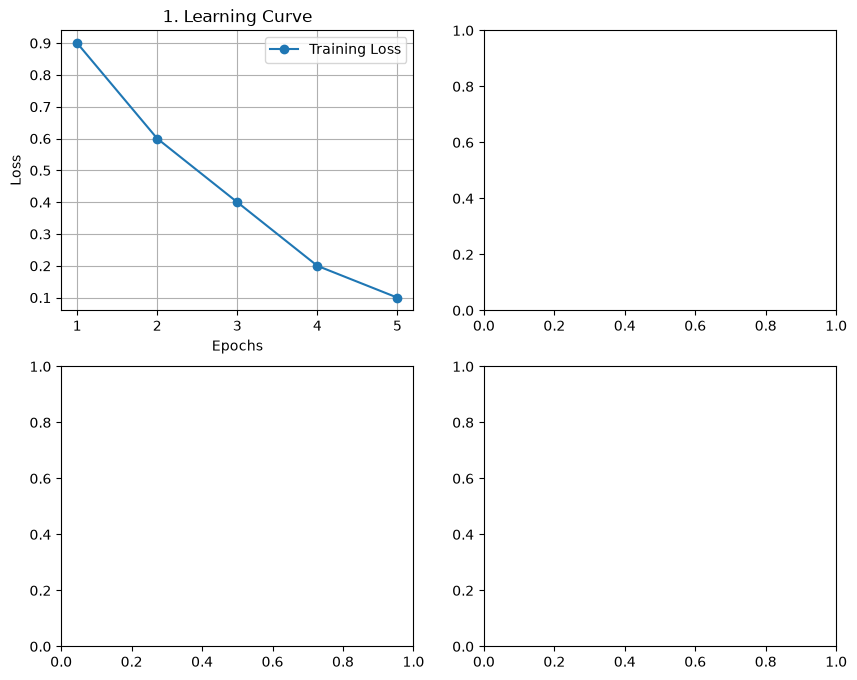

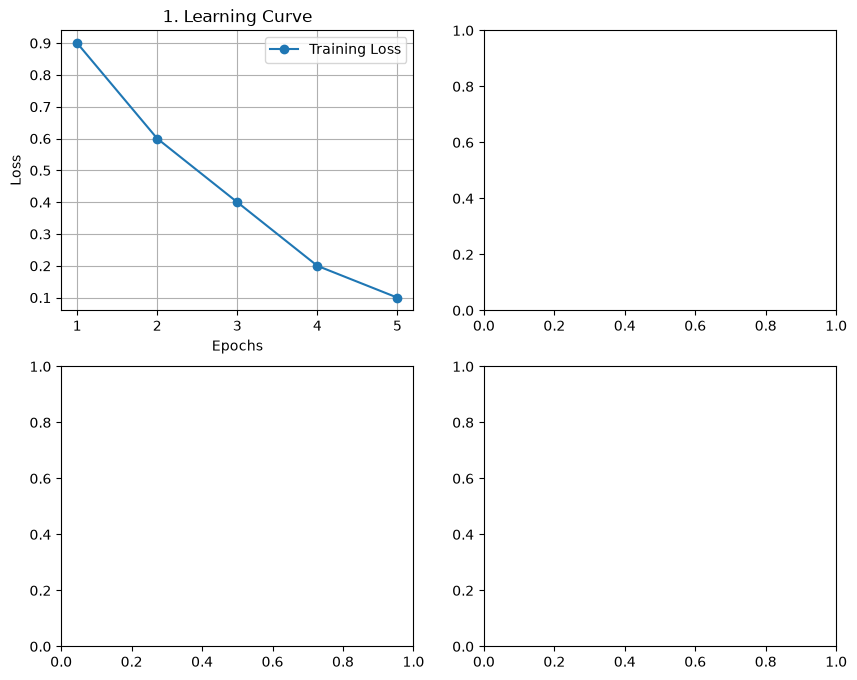

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Create the 2x2 dashboard grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# 1. LINE CHART (Top-Left)
epochs = [1, 2, 3, 4, 5]
loss = [0.9, 0.6, 0.4, 0.2, 0.1]

axes[0, 0].plot(epochs, loss, marker='o', label="Training Loss")
axes[0, 0].set_title("1. Learning Curve")
axes[0, 0].set_xlabel("Epochs")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Show the current state of the dashboard
fig

#### Step 2: Bar Chart
On the top-right axis (`axes[0, 1]`), compare the image categories. Explicitly use the parameter names for the x-axis (`x`) and the bar sizes (`height`).

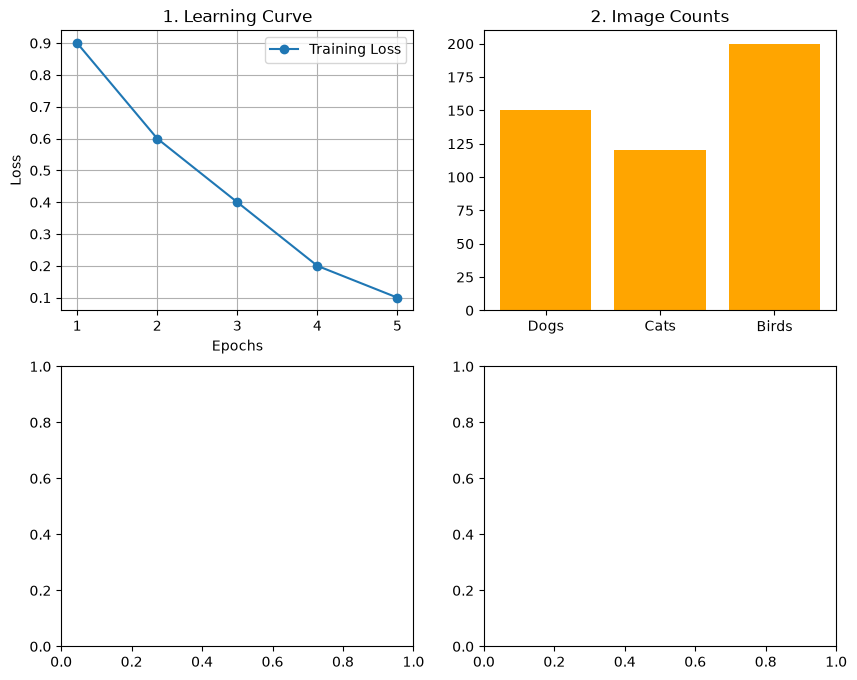

In [20]:
# 2. BAR CHART (Top-Right)
classes = ['Dogs', 'Cats', 'Birds']
counts = [150, 120, 200]

axes[0, 1].bar(x=classes, height=counts, color='orange')
axes[0, 1].set_title("2. Image Counts")

# Update and display the dashboard
fig

#### Step 3: Histogram
On the bottom-left axis (`axes[1, 0]`), show the distribution of pixel values. Define the number of intervals using the correct parameter (`bins`).

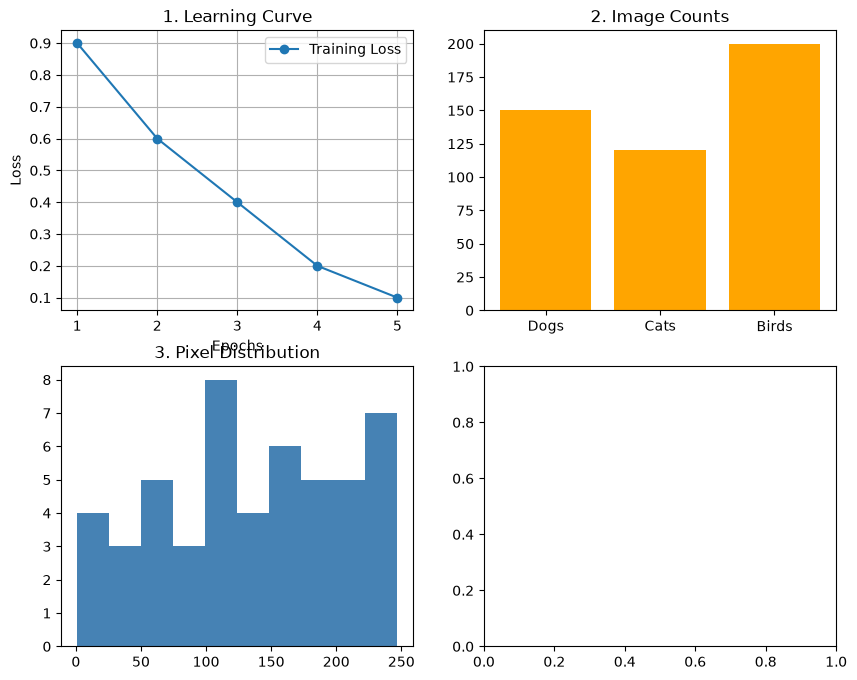

In [21]:
# 3. HISTOGRAM (Bottom-Left)
pixel_values = np.random.randint(0, 255, 50)

axes[1, 0].hist(pixel_values, bins=10, color='steelblue')
axes[1, 0].set_title("3. Pixel Distribution")

# Update and display the dashboard
fig

#### Step 4: Scatter Plot & Export
On the bottom-right axis (`axes[1, 1]`), map the coordinates using exact parameter names to check the correlation. 
Finally, use `tight_layout` to fix any overlapping text, and save your beautiful dashboard as a PNG file!

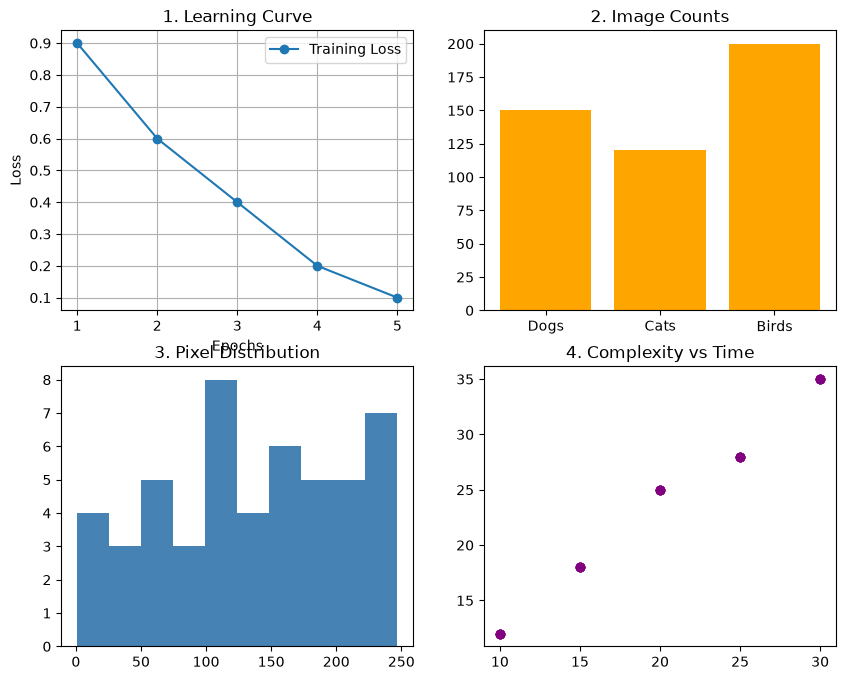

In [26]:
# 4. SCATTER PLOT (Bottom-Right)
model_complexity = [10, 15, 20, 25, 30]
training_time = [12, 18, 25, 28, 35]

axes[1, 1].scatter(x=model_complexity, y=training_time, color='purple')
axes[1, 1].set_title("4. Complexity vs Time")

# Automatically adjust spacing so titles and labels don't overlap
# plt.tight_layout()

# EXPORT: Save the entire figure to your hard drive
fig.savefig("my_dashboard.png")

# Final Dashboard Display
fig